## Importing Libraries

# EDA On Customer Shopping Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Reading & Reviewing The dataset

In [3]:
df = pd.read_csv(r'F:\Datasets\customer_shopping_data.csv')

In [4]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [6]:
df.shape

(99457, 10)

In [7]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [8]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [9]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

In [10]:
df.drop(['customer_id'],axis = 1, inplace = True)

In [11]:
df.drop(['invoice_no'],axis =1,inplace = True)

In [42]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst = True)
df['month'] = df['invoice_date'].dt.month
df

,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,month
0,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,8
1,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,12
2,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,11
3,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,5
4,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,10
...,...,...,...,...,...,...,...,...,...
99452,Female,45,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon,9
99453,Male,27,Food & Beverage,2,10.46,Cash,2021-09-22,Forum Istanbul,9
99454,Male,63,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity,3
99455,Male,56,Technology,4,4200.00,Cash,2021-03-16,Istinye Park,3


In [12]:
df.columns

Index(['gender', 'age', 'category', 'quantity', 'price', 'payment_method',
       'invoice_date', 'shopping_mall'],
      dtype='object')

## EDA Part

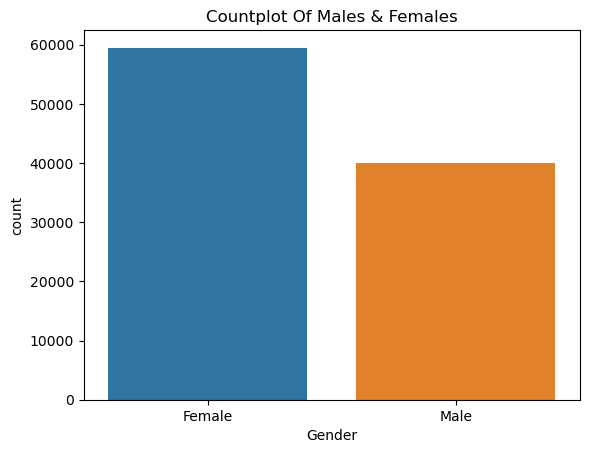

In [13]:

sns.countplot(x='gender',data=df,hue='gender')
plt.xlabel("Gender")
plt.title("Countplot Of Males & Females")
plt.show()

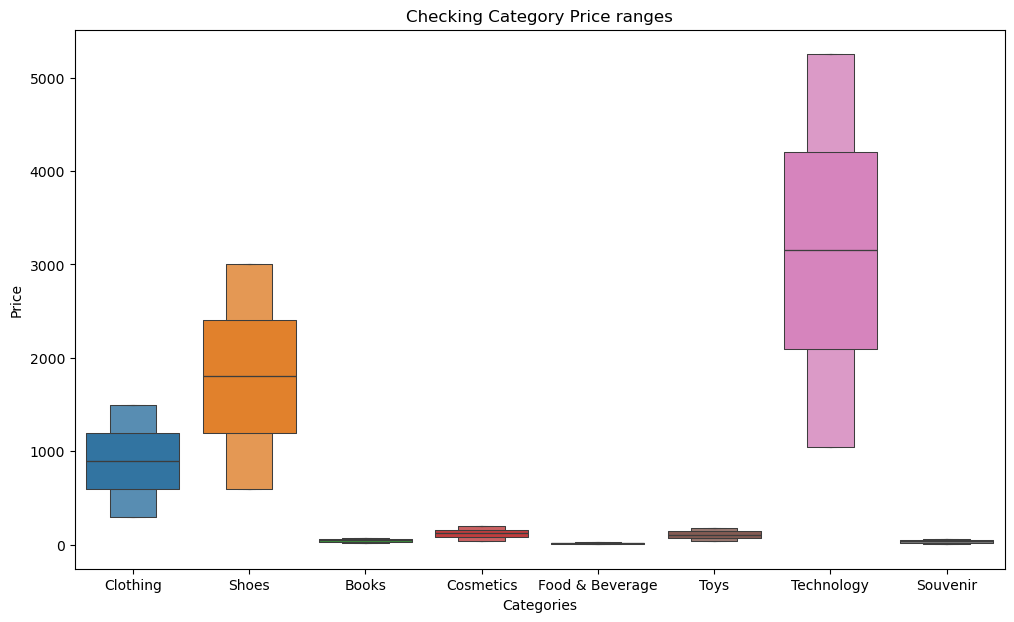

In [14]:
plt.figure(figsize=(12,7))
sns.boxenplot(x='category',y='price', data = df,hue='category')
plt.xlabel("Categories")
plt.ylabel('Price')
plt.title("Checking Category Price ranges")
plt.show()

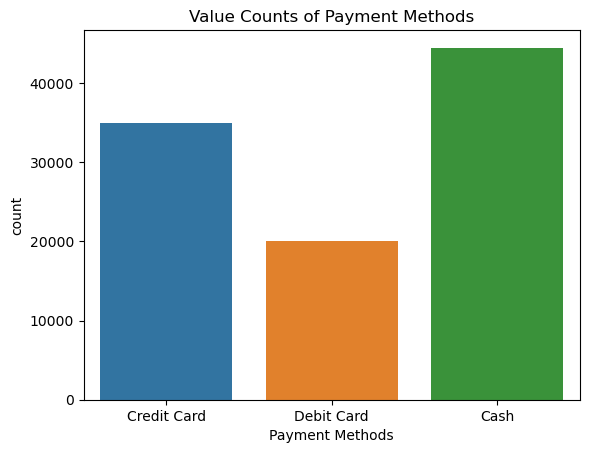

In [15]:
sns.countplot(x='payment_method',data = df,hue='payment_method')
plt.title("Value Counts of Payment Methods")
plt.xlabel("Payment Methods")
plt.show()

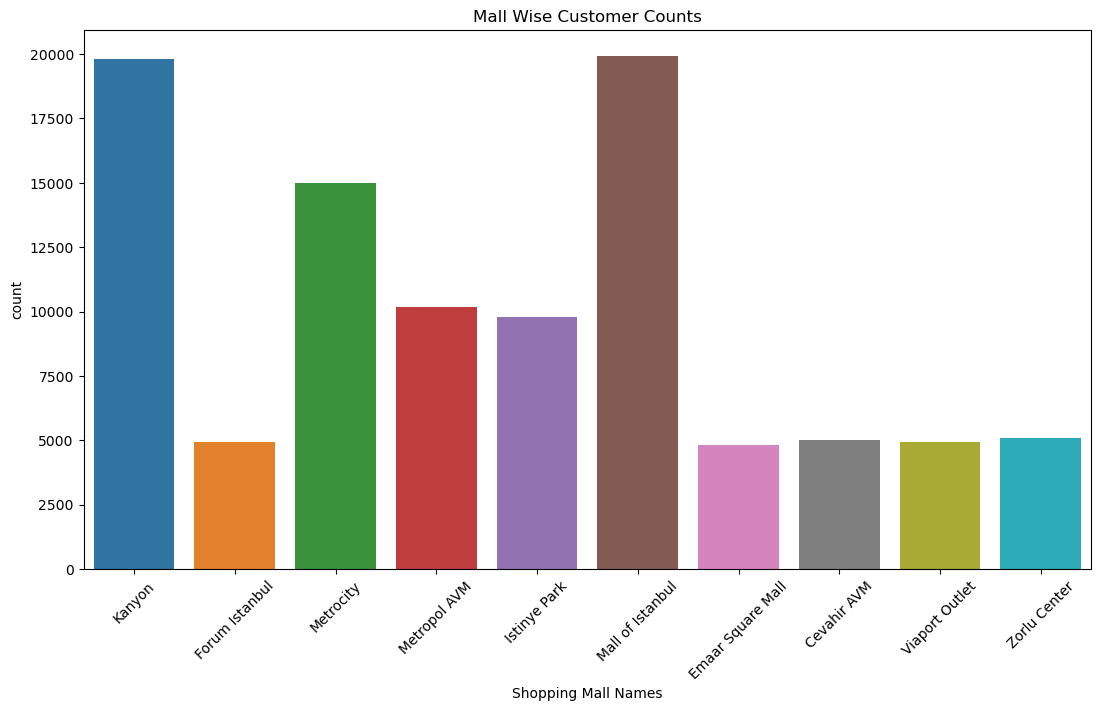

In [16]:
plt.figure(figsize=(13,7))
sns.countplot(x="shopping_mall", data= df , hue = 'shopping_mall')
plt.xticks(rotation = 45)
plt.xlabel("Shopping Mall Names")
plt.title("Mall Wise Customer Counts")
plt.show()

In [17]:
df.category.value_counts()

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

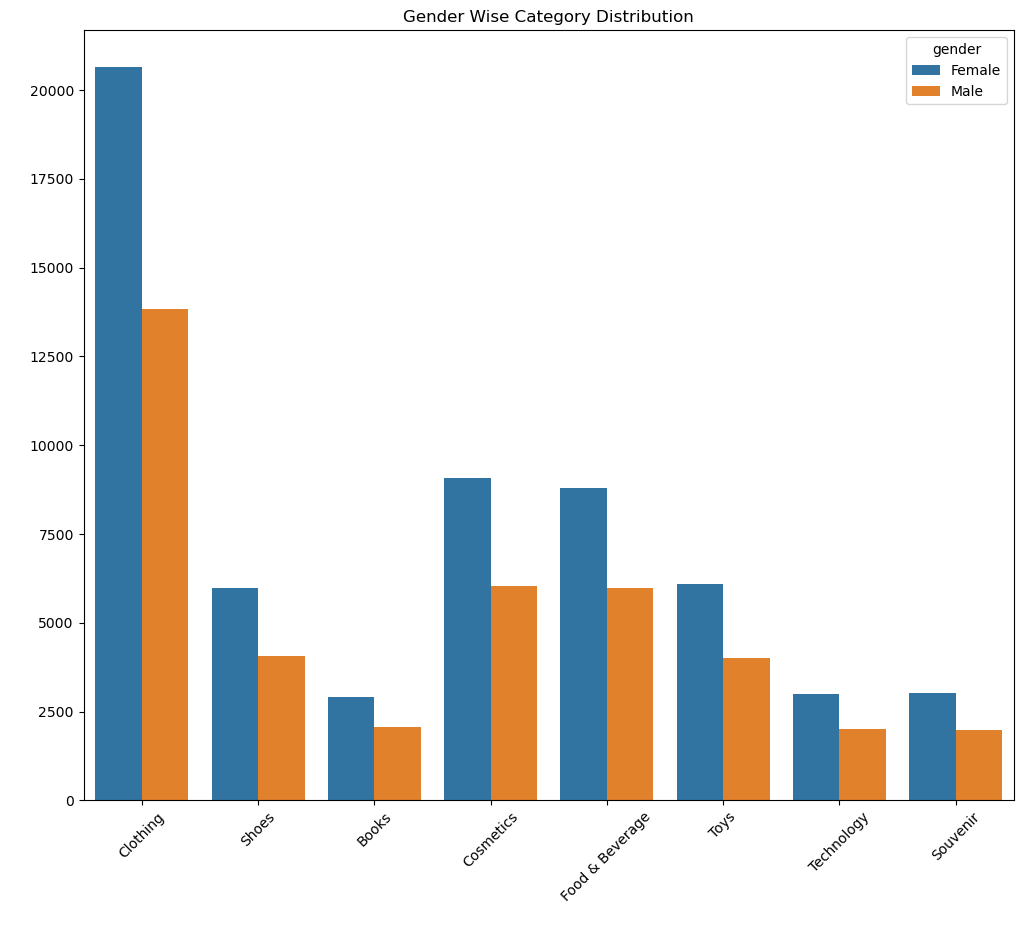

In [18]:
plt.figure(figsize=(12,10))
sns.countplot(data = df,x='category',hue='gender')
plt.xlabel(" ")
plt.ylabel(" ")
plt.xticks(rotation=45)
plt.title("Gender Wise Category Distribution")
plt.show()

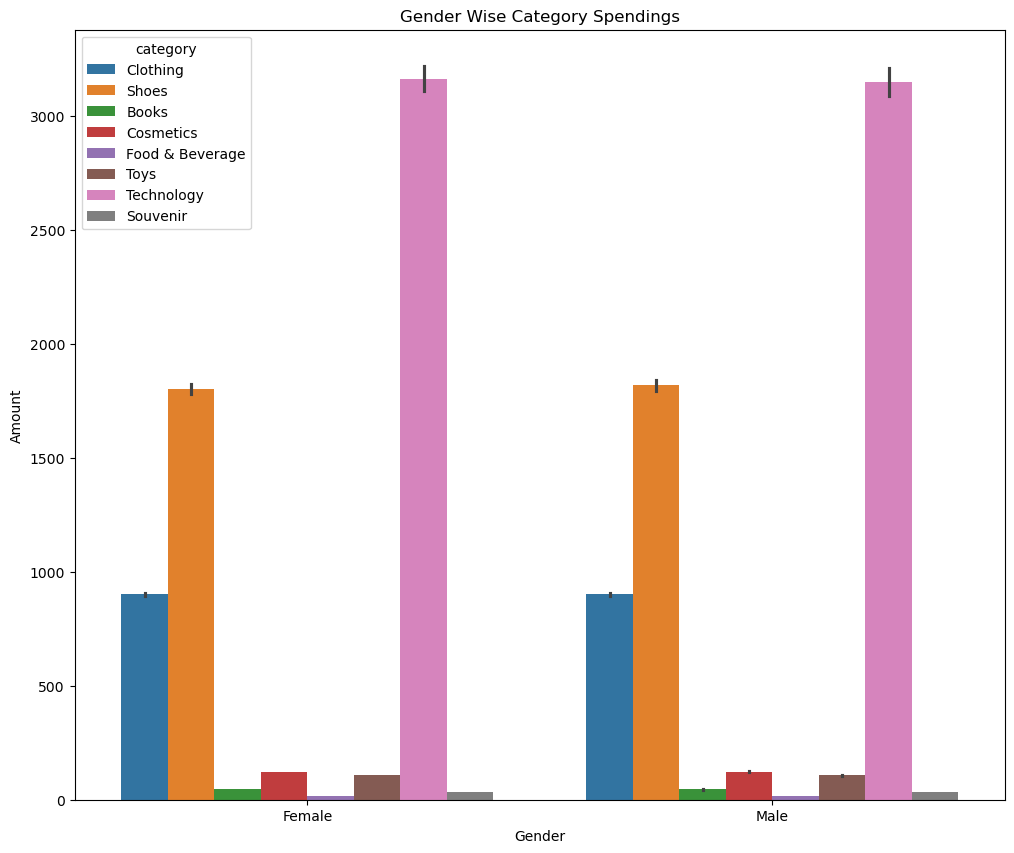

In [19]:
plt.figure(figsize=(12,10))
sns.barplot(data = df, x ='gender', y ='price' , hue = 'category')
plt.xlabel("Gender")
plt.ylabel("Amount")
plt.title("Gender Wise Category Spendings")
plt.show()

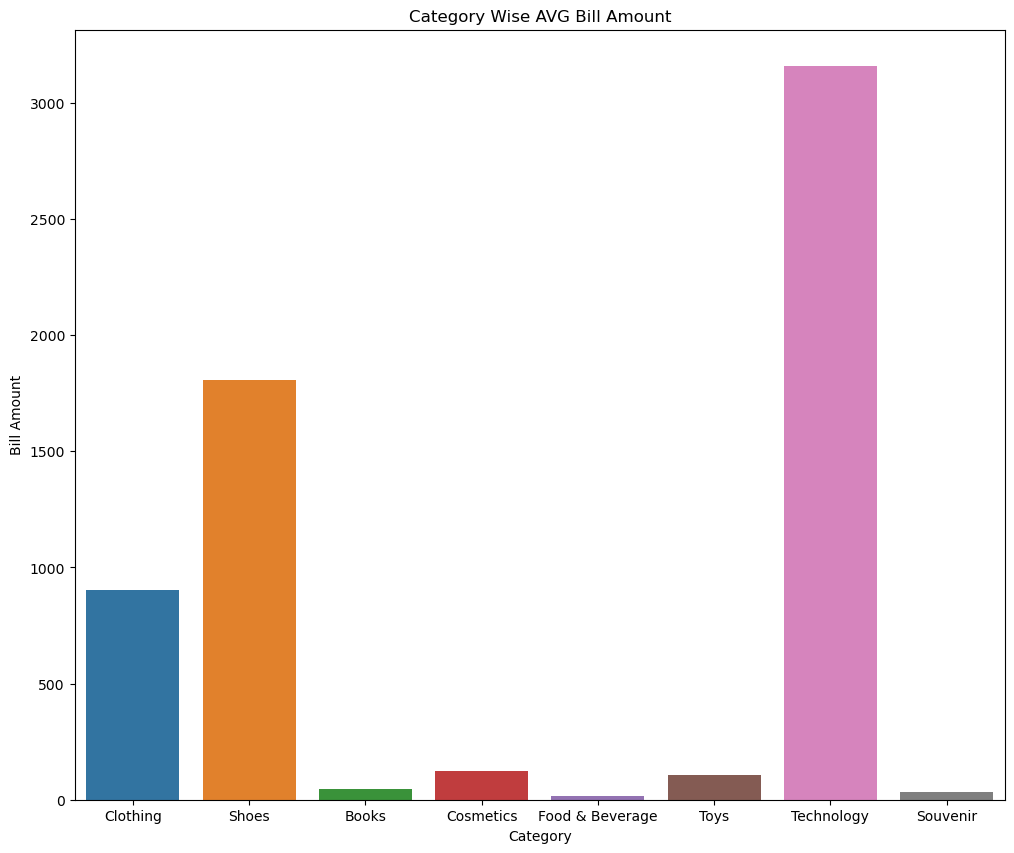

In [20]:
plt.figure(figsize=(12,10))
sns.barplot(data = df, x ='category' , y='price' , hue = 'category', ci = None)
plt.xlabel("Category")
plt.ylabel("Bill Amount")
plt.title("Category Wise AVG Bill Amount")
plt.show()

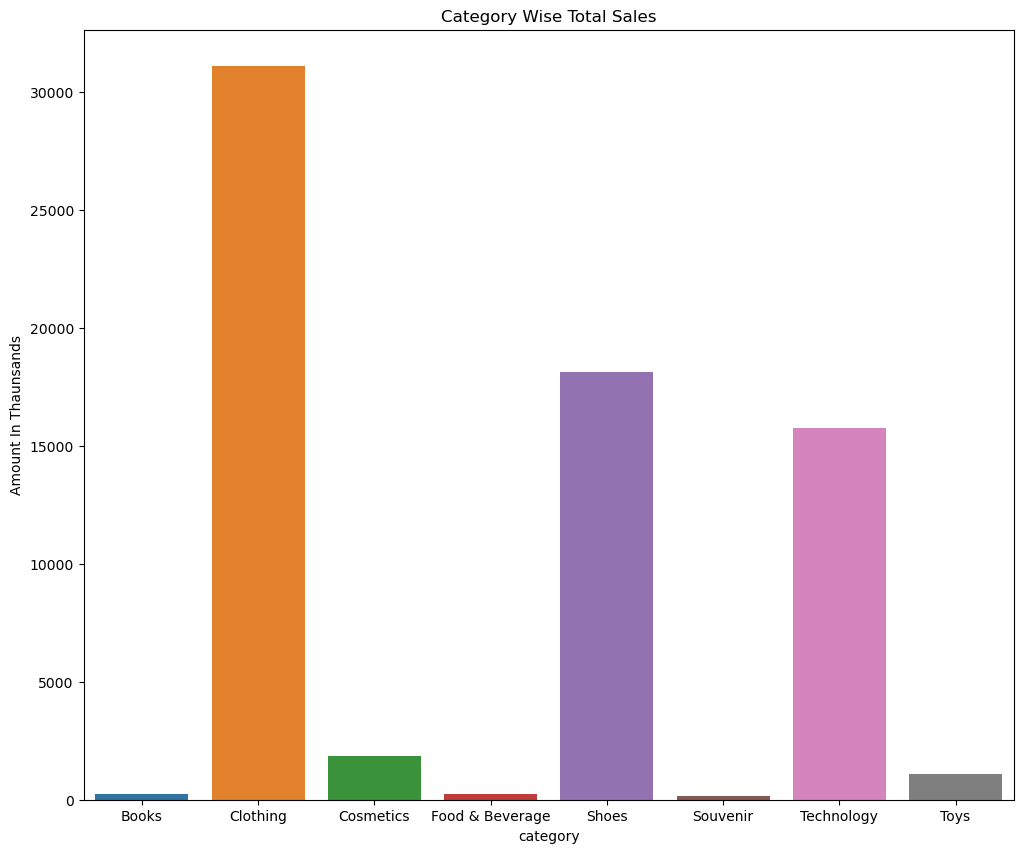

In [31]:
category_sales = pd.DataFrame(df.groupby('category')['price'].sum().reset_index())
category_sales['price'] = category_sales['price']//1000
plt.figure(figsize=(12,10))
sns.barplot(data = category_sales,x='category',y='price', hue = 'category')
plt.xlabel=('Category')
plt.ylabel('Amount In Thaunsands')
plt.title("Category Wise Total Sales")
plt.show()

In [23]:
df.head()

,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


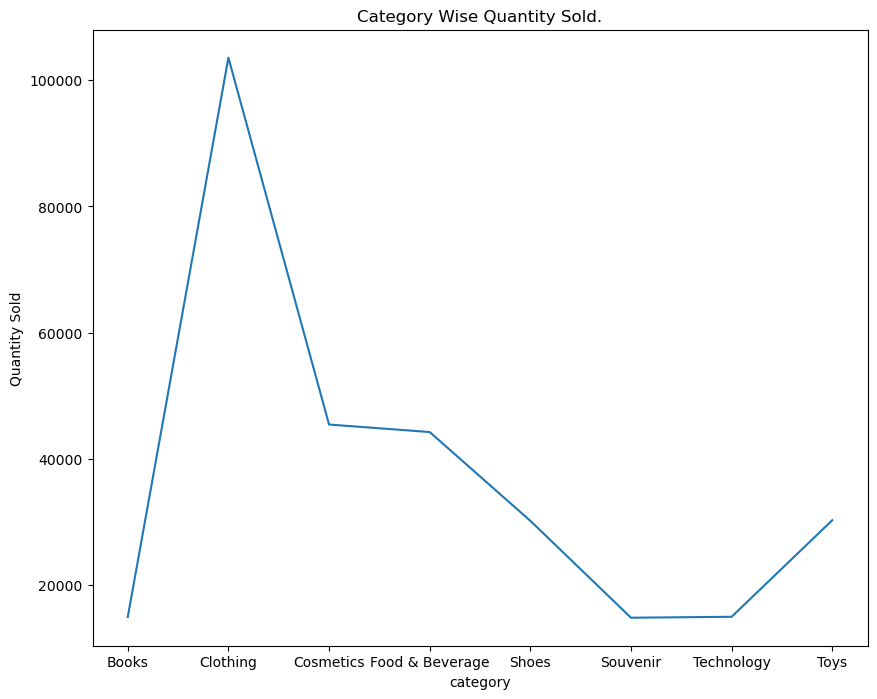

In [40]:
quantity_sold = pd.DataFrame(df.groupby('category')['quantity'].sum().reset_index())
plt.figure(figsize=(10,8))
sns.lineplot(data = quantity_sold, x= 'category' , y = 'quantity')
plt.title("Category Wise Quantity Sold.")
plt.ylabel("Quantity Sold")
plt.show()

<Axes: xlabel='invoice_date'>

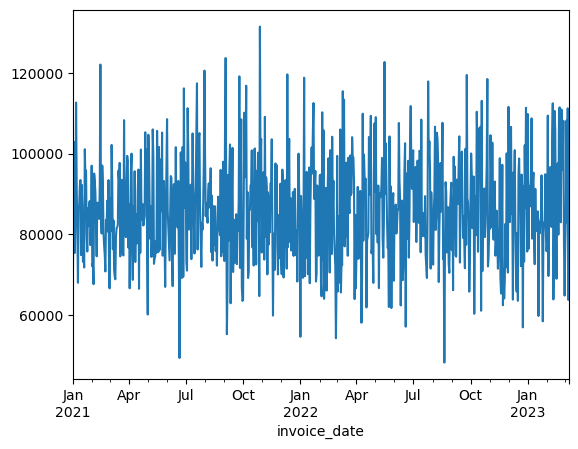

In [44]:
daily_sale = df.groupby('invoice_date')['price'].sum()
daily_sale.plot()

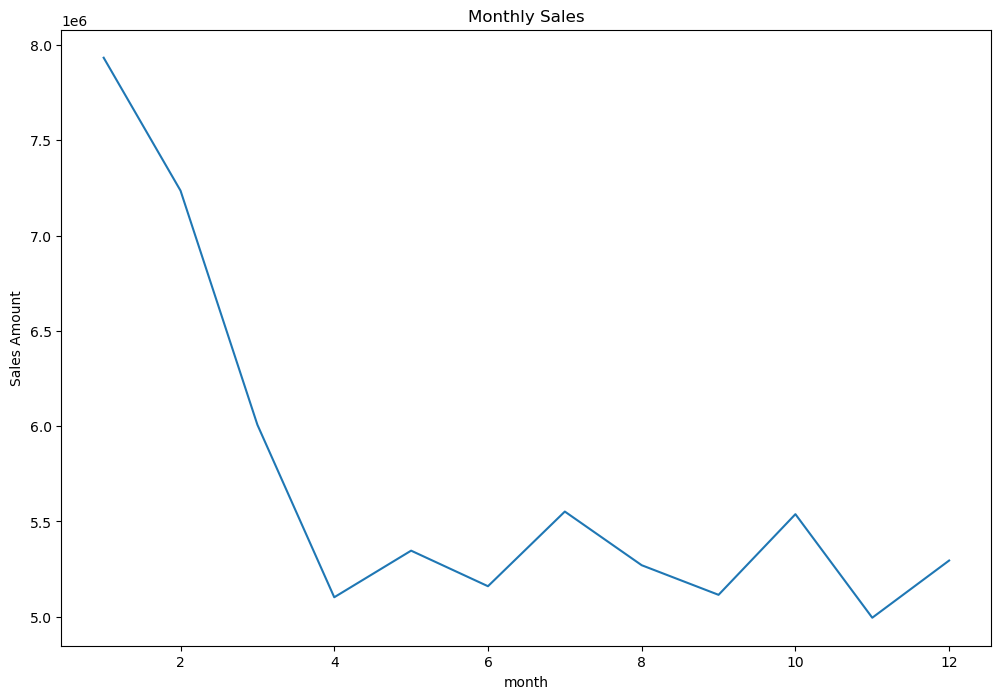

In [48]:
plt.figure(figsize=(12,8))
sns.lineplot(data = df, x = 'month' , y ='price' , estimator=sum , ci =None)
plt.title("Monthly Sales")
plt.ylabel("Sales Amount")
plt.show()

<Axes: xlabel='quantity', ylabel='Count'>

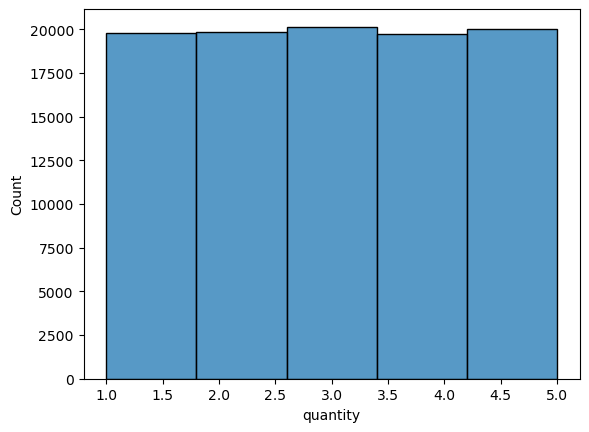

In [52]:
sns.histplot(data = df , x='quantity' , bins=5)